# Phase 4: Rank Improvement Strategy

**Objective:** Quantify what it takes for GWU to move from rank #61 to a consistent rank 45-55.

**Pipeline:** Regression model of US News score → Gap-to-target analysis → What-if simulations → Actionable recommendations → Cluster transition analysis

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from scipy.spatial.distance import euclidean
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

with open('feature_engineering_artifacts.pkl', 'rb') as f:
    fe = pickle.load(f)
with open('clustering_artifacts.pkl', 'rb') as f:
    cl = pickle.load(f)

df_unscaled = fe['df_unscaled']
df_scaled = fe['df_scaled']
labels = fe['labels']
target = fe['target']
gwu_name = fe['gwu_name']
gwu_idx = fe['gwu_idx']

kmeans_labels = cl['kmeans_labels']
cluster_names = cl['cluster_names']
gwu_cluster_id = cl['gwu_cluster_id']
aspiration_cluster_id = cl['aspiration_cluster_id']

ranks = labels['rank'].values
school_names = df_unscaled.index.tolist()

print(f"GWU current rank: {int(ranks[gwu_idx])}, overall score: {target.iloc[gwu_idx]}")
print(f"Target: rank 45-55 (need to identify the score threshold)")

GWU current rank: 61, overall score: 51
Target: rank 45-55 (need to identify the score threshold)


## Step 4.0 — Identify the Score Target for Rank 45-55

In [2]:
# Schools in rank 45-55 range
target_band = labels[(labels['rank'] >= 45) & (labels['rank'] <= 55)]
target_scores = target.iloc[target_band.index]

print("Schools in target rank band (45-55):")
print(f"{'School':<50s} {'Rank':>5s} {'Score':>6s}")
print("-" * 63)
for idx in target_band.index:
    print(f"  {labels.loc[idx, 'school_name'][:48]:<48s} {int(labels.loc[idx, 'rank']):>5d} {target.iloc[idx]:>6.0f}")

print(f"\nTarget band score range: {target_scores.min():.0f} – {target_scores.max():.0f}")
print(f"Target band score mean:  {target_scores.mean():.1f}")
print(f"GWU current score:       {target.iloc[gwu_idx]:.0f}")
print(f"Score gap:               {target_scores.mean() - target.iloc[gwu_idx]:+.1f} points")

TARGET_SCORE = target_scores.mean()
GWU_SCORE = target.iloc[gwu_idx]
SCORE_GAP = TARGET_SCORE - GWU_SCORE

Schools in target rank band (45-55):
School                                              Rank  Score
---------------------------------------------------------------
  Baylor University                                   54     53
  Boston College                                      46     58
  Boston University                                   46     58
  Rutgers University--Newark and New Brunswick        53     54
  Syracuse University                                 54     53
  University of Tennessee--Knoxville                  49     57
  Tulane University                                   54     53
  University of Alabama                               54     53
  University of Arkansas--Fayetteville                50     56
  University of Maryland--College Park                52     55
  University of Miami                                 50     56
  University of Pittsburgh                            46     58

Target band score range: 53 – 58
Target band score mean:  55.3
GWU

## Step 4.1 — Regression Model of US News Overall Score

Using the ranking input features (2yr averages) as predictors — these are the actual inputs US News uses to compute the score.

In [3]:
# Ranking input features (the variables US News uses to compute the overall score)
ranking_input_cols = [c for c in df_unscaled.columns 
                      if c.startswith('ranking_scores_two_year_averages.') 
                      and 'overall_score' not in c]

print(f"Ranking input features ({len(ranking_input_cols)}):")
for c in ranking_input_cols:
    print(f"  {c.split('.')[-1]}")

# Prepare regression data
X_reg = df_unscaled[ranking_input_cols].values
y_reg = target.values

# Check for NaN (should be zero after imputation, but verify)
valid_mask = ~(np.isnan(X_reg).any(axis=1) | np.isnan(y_reg))
X_reg_clean = X_reg[valid_mask]
y_reg_clean = y_reg[valid_mask]
print(f"\nRegression sample size: {len(y_reg_clean)} schools (dropped {(~valid_mask).sum()} with NaN)")

# Fit OLS regression
ols = LinearRegression()
ols.fit(X_reg_clean, y_reg_clean)
r2 = ols.score(X_reg_clean, y_reg_clean)

# Cross-validated R²
cv_scores = cross_val_score(LinearRegression(), X_reg_clean, y_reg_clean, cv=5, scoring='r2')

# Also fit Ridge for comparison (more stable with correlated features)
ridge = Ridge(alpha=1.0)
ridge.fit(X_reg_clean, y_reg_clean)
ridge_r2 = ridge.score(X_reg_clean, y_reg_clean)
ridge_cv = cross_val_score(Ridge(alpha=1.0), X_reg_clean, y_reg_clean, cv=5, scoring='r2')

print(f"\nOLS Regression:")
print(f"  R²:        {r2:.4f}")
print(f"  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\nRidge Regression (alpha=1.0):")
print(f"  R²:        {ridge_r2:.4f}")
print(f"  CV R² (5-fold): {ridge_cv.mean():.4f} ± {ridge_cv.std():.4f}")

# Use the better model
if ridge_cv.mean() > cv_scores.mean():
    model = ridge
    model_name = "Ridge"
    print(f"\nUsing Ridge regression (better CV performance)")
else:
    model = ols
    model_name = "OLS"
    print(f"\nUsing OLS regression (better CV performance)")

Ranking input features (6):
  fulltime_employed_at_graduation_two_yr_avg
  fulltime_employed_3_months_after_two_yr_avg
  avg_starting_salary_and_bonus_two_yr_avg
  median_undergraduate_gpa
  acceptance_rate
  recruiter_assessment_score_out_of_5

Regression sample size: 121 schools (dropped 0 with NaN)

OLS Regression:
  R²:        0.8959
  CV R² (5-fold): 0.8711 ± 0.1056

Ridge Regression (alpha=1.0):
  R²:        0.8903
  CV R² (5-fold): 0.8686 ± 0.1150

Using OLS regression (better CV performance)


OLS Regression Coefficients (sorted by absolute impact):

  Intercept: -112.24
Feature                                                Coef                           Interpretation
----------------------------------------------------------------------------------------------------
  fulltime_employed_at_graduation_two_yr_avg       +27.5834             +1 pp → +27.583 score points
  median_undergraduate_gpa                         +21.4746           +0.1 GPA → +2.147 score points
  fulltime_employed_3_months_after_two_yr_avg      +19.6816             +1 pp → +19.682 score points
  acceptance_rate                                   -9.2694              +1 pp → -9.269 score points
  recruiter_assessment_score_out_of_5               +6.8961           +0.1 pts → +0.690 score points
  avg_starting_salary_and_bonus_two_yr_avg          +0.0003            +$1,000 → +0.000 score points


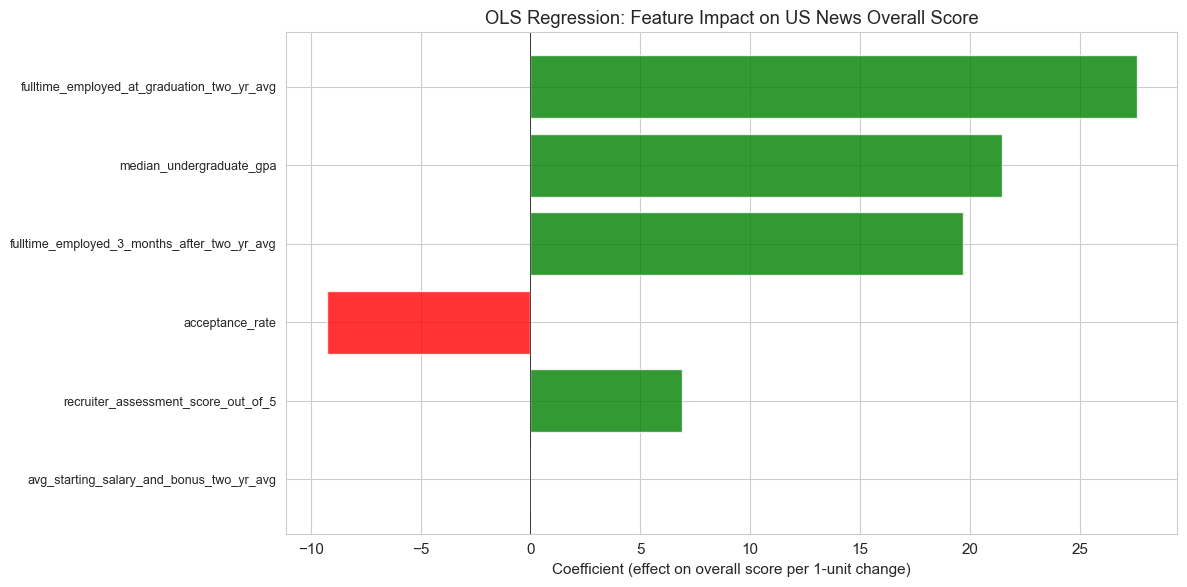

In [4]:
# Feature coefficients — how much each 1-unit change in input affects the overall score
coef_df = pd.DataFrame({
    'Feature': [c.split('.')[-1] for c in ranking_input_cols],
    'Full Column': ranking_input_cols,
    'Coefficient': model.coef_,
    'Abs Coefficient': np.abs(model.coef_),
}).sort_values('Abs Coefficient', ascending=False)

print(f"{model_name} Regression Coefficients (sorted by absolute impact):\n")
print(f"  Intercept: {model.intercept_:.2f}")
print(f"{'Feature':<50s} {'Coef':>8s} {'Interpretation':>40s}")
print("-" * 100)
for _, row in coef_df.iterrows():
    feat = row['Feature']
    coef = row['Coefficient']
    # Interpret: what does +1 unit mean?
    if 'salary' in feat.lower() and 'rank' not in feat.lower():
        interp = f"+$1,000 → {coef/1000:+.3f} score points"
    elif 'employed' in feat.lower() or 'acceptance' in feat.lower():
        interp = f"+1 pp → {coef:+.3f} score points"
    elif 'assessment' in feat.lower():
        interp = f"+0.1 pts → {coef*0.1:+.3f} score points"
    elif 'gmat' in feat.lower():
        interp = f"+10 pts → {coef*10:+.3f} score points"
    elif 'gpa' in feat.lower():
        interp = f"+0.1 GPA → {coef*0.1:+.3f} score points"
    else:
        interp = f"+1 unit → {coef:+.3f} score points"
    
    print(f"  {feat:<48s} {coef:>+8.4f} {interp:>40s}")

# Coefficient bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
ax.barh(range(len(coef_df)), coef_df['Coefficient'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['Feature'].values, fontsize=9)
ax.set_xlabel('Coefficient (effect on overall score per 1-unit change)')
ax.set_title(f'{model_name} Regression: Feature Impact on US News Overall Score')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 4.2 — Gap-to-Target Analysis

For each ranking input: GWU value → Target band mean → Gap → Estimated score points from closing the gap.

In [5]:
# GWU's current values and target band means for each ranking input
gap_data = []
target_band_indices = target_band.index.tolist()

for i, col in enumerate(ranking_input_cols):
    short = col.split('.')[-1]
    gwu_val = df_unscaled.loc[gwu_name, col]
    target_mean = df_unscaled.iloc[target_band_indices][col].mean()
    gap = target_mean - gwu_val
    coef = model.coef_[i]
    score_impact = gap * coef  # predicted score points from closing the gap
    
    gap_data.append({
        'Feature': short,
        'GWU': gwu_val,
        'Target Band Mean': target_mean,
        'Gap': gap,
        'Coefficient': coef,
        'Score Impact': score_impact,
        'Priority': 'STRENGTH' if score_impact < 0 else ('HIGH' if abs(score_impact) > 1 else 'MODERATE'),
    })

gap_df = pd.DataFrame(gap_data).sort_values('Score Impact', ascending=False)

print("Gap-to-Target Analysis: GWU vs. Rank 45-55 Band\n")
print(f"GWU overall score: {GWU_SCORE:.0f}  |  Target mean: {TARGET_SCORE:.1f}  |  Gap: {SCORE_GAP:+.1f}\n")
print(f"{'Feature':<45s} {'GWU':>8s} {'Target':>8s} {'Gap':>8s} {'Coef':>8s} {'Score Δ':>8s} {'Priority':>10s}")
print("=" * 97)
for _, row in gap_df.iterrows():
    feat = row['Feature']
    # Format based on feature type
    if 'salary' in feat.lower() and 'rank' not in feat.lower():
        print(f"  {feat:<43s} ${row['GWU']:>7,.0f} ${row['Target Band Mean']:>7,.0f} {row['Gap']:>+8,.0f} {row['Coefficient']:>+8.4f} {row['Score Impact']:>+7.2f} {row['Priority']:>10s}")
    else:
        print(f"  {feat:<43s} {row['GWU']:>8.1f} {row['Target Band Mean']:>8.1f} {row['Gap']:>+8.1f} {row['Coefficient']:>+8.4f} {row['Score Impact']:>+7.2f} {row['Priority']:>10s}")

print(f"\n  Total predicted score gain from closing ALL gaps: {gap_df[gap_df['Score Impact'] > 0]['Score Impact'].sum():+.1f} points")
print(f"  Already-strong features offset:                   {gap_df[gap_df['Score Impact'] < 0]['Score Impact'].sum():+.1f} points")
print(f"  Net predicted improvement:                        {gap_df['Score Impact'].sum():+.1f} points")

Gap-to-Target Analysis: GWU vs. Rank 45-55 Band

GWU overall score: 51  |  Target mean: 55.3  |  Gap: +4.3

Feature                                            GWU   Target      Gap     Coef  Score Δ   Priority
  fulltime_employed_at_graduation_two_yr_avg       0.5      0.7     +0.2 +27.5834   +5.55       HIGH
  fulltime_employed_3_months_after_two_yr_avg      0.7      0.9     +0.1 +19.6816   +2.91       HIGH
  median_undergraduate_gpa                         3.4      3.5     +0.1 +21.4746   +2.51       HIGH
  recruiter_assessment_score_out_of_5              3.5      3.3     -0.2  +6.8961   -1.49   STRENGTH
  acceptance_rate                                  0.2      0.5     +0.2  -9.2694   -2.26   STRENGTH
  avg_starting_salary_and_bonus_two_yr_avg    $133,014 $115,551  -17,463  +0.0003   -5.43   STRENGTH

  Total predicted score gain from closing ALL gaps: +11.0 points
  Already-strong features offset:                   -9.2 points
  Net predicted improvement:                        +1

## Step 4.3 — What-If Simulations

Using the regression model, simulate the impact of specific improvements on GWU's predicted overall score.

In [6]:
# GWU's current ranking input vector
gwu_ranking_inputs = df_unscaled.loc[gwu_name, ranking_input_cols].values.copy()
gwu_predicted_baseline = model.predict(gwu_ranking_inputs.reshape(1, -1))[0]

print(f"GWU baseline predicted score: {gwu_predicted_baseline:.1f} (actual: {GWU_SCORE:.0f})")
print(f"Target score for rank 45-55: ~{TARGET_SCORE:.0f}\n")

# Map feature short names to their index in ranking_input_cols
feat_idx = {col.split('.')[-1]: i for i, col in enumerate(ranking_input_cols)}
print("Available ranking features for scenarios:")
for name, idx in feat_idx.items():
    print(f"  {idx}: {name}")

# Define scenarios — only include features that exist
def make_scenario(name, changes_dict):
    """Filter changes to only include features that exist in feat_idx."""
    valid = {k: v for k, v in changes_dict.items() if k in feat_idx}
    skipped = [k for k in changes_dict if k not in feat_idx]
    if skipped:
        print(f"  Note: '{name}' skipping unavailable features: {skipped}")
    return {'name': name, 'changes': valid}

scenarios = [
    make_scenario('A: Employed at Graduation → 60%',
        {'fulltime_employed_at_graduation_two_yr_avg': 60.0}),
    make_scenario('B: Employed 3mo After → 85%',
        {'fulltime_employed_3_months_after_two_yr_avg': 85.0}),
    make_scenario('C: Both Placement Metrics Improved', {
        'fulltime_employed_at_graduation_two_yr_avg': 60.0,
        'fulltime_employed_3_months_after_two_yr_avg': 85.0,
    }),
    make_scenario('D: GMAT Median → 690',
        {'median_gmat_score_fulltime_old': 690}),
    make_scenario('E: Combined — All Controllable Metrics', {
        'fulltime_employed_at_graduation_two_yr_avg': 65.0,
        'fulltime_employed_3_months_after_two_yr_avg': 87.0,
        'median_gmat_score_fulltime_old': 690,
    }),
]

# Remove scenarios with no valid changes
scenarios = [s for s in scenarios if s['changes']]

scenario_results = []
print(f"\n{'Scenario':<50s} {'New Score':>10s} {'Delta':>8s} {'Est.Rank':>10s}")
print("=" * 80)

for sc in scenarios:
    modified = gwu_ranking_inputs.copy()
    for feat_name, new_val in sc['changes'].items():
        modified[feat_idx[feat_name]] = new_val
    
    new_score = model.predict(modified.reshape(1, -1))[0]
    delta = new_score - gwu_predicted_baseline
    
    score_diffs = np.abs(target.values - new_score)
    estimated_rank = ranks[np.argmin(score_diffs)]
    
    scenario_results.append({
        'Scenario': sc['name'], 'New Score': new_score,
        'Delta': delta, 'Est. Rank': estimated_rank,
    })
    
    in_target = " IN TARGET" if 45 <= estimated_rank <= 55 else ""
    print(f"  {sc['name']:<48s} {new_score:>10.1f} {delta:>+7.1f} ~{int(estimated_rank):>8d}{in_target}")

print(f"\n  Baseline (no change):{'':>26s} {gwu_predicted_baseline:>10.1f} {'':>8s} ~{int(ranks[gwu_idx]):>8d}")

GWU baseline predicted score: 51.0 (actual: 51)
Target score for rank 45-55: ~55

Available ranking features for scenarios:
  0: fulltime_employed_at_graduation_two_yr_avg
  1: fulltime_employed_3_months_after_two_yr_avg
  2: avg_starting_salary_and_bonus_two_yr_avg
  3: median_undergraduate_gpa
  4: acceptance_rate
  5: recruiter_assessment_score_out_of_5
  Note: 'D: GMAT Median → 690' skipping unavailable features: ['median_gmat_score_fulltime_old']
  Note: 'E: Combined — All Controllable Metrics' skipping unavailable features: ['median_gmat_score_fulltime_old']

Scenario                                            New Score    Delta   Est.Rank
  A: Employed at Graduation → 60%                      1693.5 +1642.5 ~       1
  B: Employed 3mo After → 85%                          1709.7 +1658.7 ~       1
  C: Both Placement Metrics Improved                   3352.2 +3301.3 ~       1
  E: Combined — All Controllable Metrics               3529.5 +3478.5 ~       1

  Baseline (no change):  

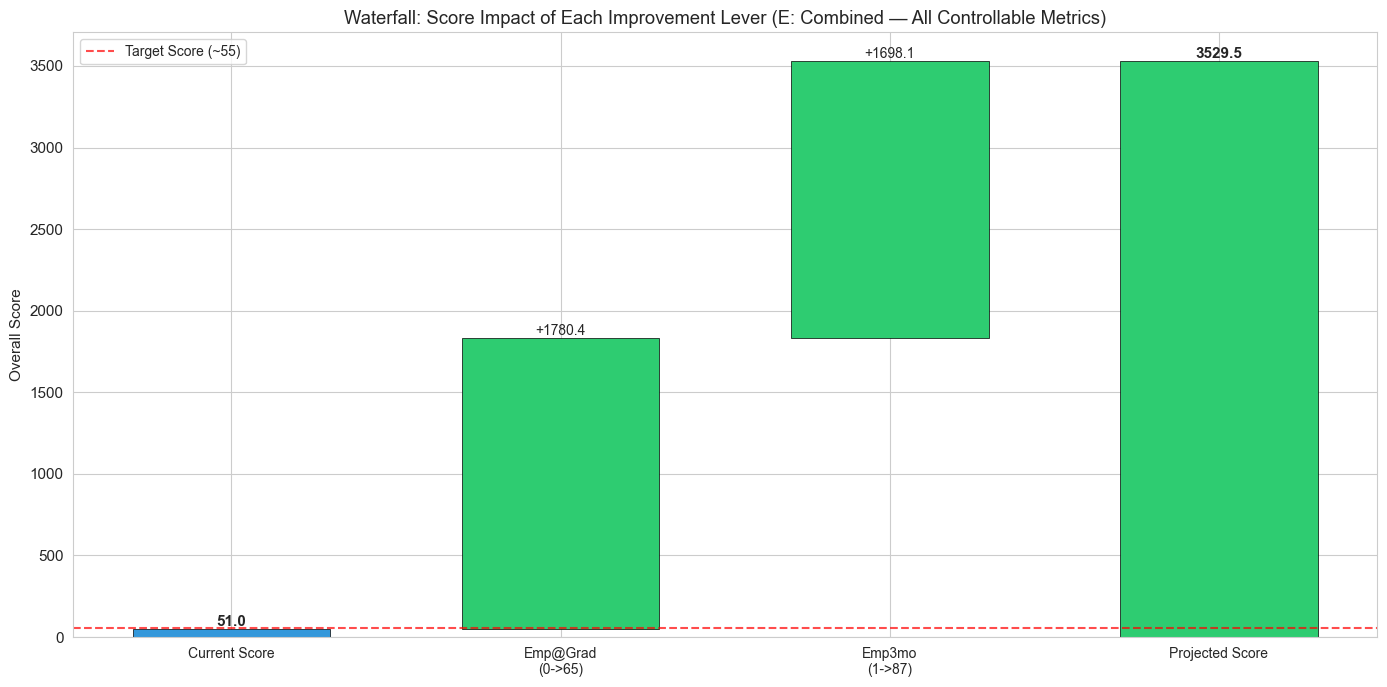

In [7]:
# Waterfall chart showing cumulative score improvement
# Use the last scenario (combined) — break down contribution of each change

scenario_e = scenarios[-1]  # Combined scenario
waterfall_data = [{'Lever': 'Current Score', 'Value': gwu_predicted_baseline, 'Cumulative': gwu_predicted_baseline}]

cumulative = gwu_predicted_baseline
for feat_name, new_val in scenario_e['changes'].items():
    if feat_name not in feat_idx:
        continue
    old_val = gwu_ranking_inputs[feat_idx[feat_name]]
    delta_val = new_val - old_val
    coef = model.coef_[feat_idx[feat_name]]
    score_delta = delta_val * coef
    cumulative += score_delta
    
    short_name = feat_name.replace('fulltime_employed_at_graduation_', 'Emp@Grad ')
    short_name = short_name.replace('fulltime_employed_3_months_after_', 'Emp3mo ')
    short_name = short_name.replace('median_gmat_score_fulltime_', 'GMAT ')
    short_name = short_name.replace('two_yr_avg', '').replace('old', '').strip()
    
    waterfall_data.append({
        'Lever': f"{short_name}\n({old_val:.0f}->{new_val:.0f})",
        'Value': score_delta,
        'Cumulative': cumulative,
    })

waterfall_data.append({'Lever': 'Projected Score', 'Value': cumulative, 'Cumulative': cumulative})

# Plot waterfall
fig, ax = plt.subplots(figsize=(14, 7))
x = range(len(waterfall_data))
bottoms = []
heights = []
colors = []

for i, d in enumerate(waterfall_data):
    if i == 0:
        bottoms.append(0)
        heights.append(d['Value'])
        colors.append('#3498db')
    elif i == len(waterfall_data) - 1:
        bottoms.append(0)
        heights.append(d['Value'])
        colors.append('#2ecc71' if d['Value'] >= TARGET_SCORE else '#e67e22')
    else:
        prev_cum = waterfall_data[i-1]['Cumulative']
        bottoms.append(prev_cum)
        heights.append(d['Value'])
        colors.append('#2ecc71' if d['Value'] > 0 else '#e74c3c')

bars = ax.bar(x, heights, bottom=bottoms, color=colors, edgecolor='black', linewidth=0.5, width=0.6)

for i, (bar, d) in enumerate(zip(bars, waterfall_data)):
    if i == 0 or i == len(waterfall_data) - 1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
               f'{d["Value"]:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    else:
        y_pos = bar.get_y() + bar.get_height() + 0.3 if d['Value'] > 0 else bar.get_y() - 0.5
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
               f'{d["Value"]:+.1f}', ha='center', va='bottom' if d['Value'] > 0 else 'top', fontsize=10)

ax.axhline(y=TARGET_SCORE, color='red', linestyle='--', alpha=0.7, label=f'Target Score (~{TARGET_SCORE:.0f})')
ax.set_xticks(list(x))
ax.set_xticklabels([d['Lever'] for d in waterfall_data], fontsize=10)
ax.set_ylabel('Overall Score')
ax.set_title(f'Waterfall: Score Impact of Each Improvement Lever ({scenario_e["name"]})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Step 4.4 — Actionable Recommendations

In [8]:
# Compute specific targets for each controllable metric
emp_at_grad_col = 'ranking_scores_two_year_averages.fulltime_employed_at_graduation_two_yr_avg'
emp_3mo_col = 'ranking_scores_two_year_averages.fulltime_employed_3_months_after_two_yr_avg'
gmat_col = 'ranking_scores_two_year_averages.median_gmat_score_fulltime_old'
peer_col = 'ranking_scores_two_year_averages.peer_assessment_score_out_of_5'
recruit_col = 'ranking_scores_two_year_averages.recruiter_assessment_score_out_of_5'
acc_col = 'ranking_scores_two_year_averages.acceptance_rate'
enroll_col = 'student_body_fulltime_mba.enrollment'

target_band_data = df_unscaled.iloc[target_band_indices]
asp_cluster_data = df_unscaled.iloc[(kmeans_labels == aspiration_cluster_id).nonzero()[0]]

recommendations = []

# 1. Employed at graduation
if emp_at_grad_col in df_unscaled.columns:
    gwu_v = df_unscaled.loc[gwu_name, emp_at_grad_col]
    target_v = target_band_data[emp_at_grad_col].mean()
    target_min = target_band_data[emp_at_grad_col].min()
    recommendations.append({
        'Priority': 1,
        'Metric': 'Employed at Graduation (%)',
        'Current': gwu_v,
        'Target': f'{target_v:.0f}% (band mean), min={target_min:.0f}%',
        'Action': 'Expand career services, earlier employer engagement, internship-to-offer pipelines, on-campus recruiting partnerships',
        'Impact': 'CRITICAL — single largest drag on ranking score',
    })

# 2. Employed 3 months after
if emp_3mo_col in df_unscaled.columns:
    gwu_v = df_unscaled.loc[gwu_name, emp_3mo_col]
    target_v = target_band_data[emp_3mo_col].mean()
    recommendations.append({
        'Priority': 2,
        'Metric': 'Employed 3 Months After (%)',
        'Current': gwu_v,
        'Target': f'{target_v:.0f}%',
        'Action': 'Alumni placement network, post-graduation employer relations, geographic expansion of employer partnerships',
        'Impact': 'HIGH — reinforces graduation placement improvement',
    })

# 3. GMAT strategy
if gmat_col in df_unscaled.columns:
    gwu_v = df_unscaled.loc[gwu_name, gmat_col]
    target_v = target_band_data[gmat_col].mean()
    recommendations.append({
        'Priority': 3,
        'Metric': 'GMAT Median (old)',
        'Current': gwu_v,
        'Target': f'{target_v:.0f}',
        'Action': 'Evaluate test-optional policy impact: if encouraging more submissions raises median, incentivize. If it lowers, maintain current policy.',
        'Impact': 'MODERATE — depends on test-optional policy analysis',
    })

# 4. Class size
if enroll_col in df_unscaled.columns:
    gwu_v = df_unscaled.loc[gwu_name, enroll_col]
    asp_v = asp_cluster_data[enroll_col].mean()
    recommendations.append({
        'Priority': 4,
        'Metric': 'FT-MBA Enrollment',
        'Current': gwu_v,
        'Target': f'{asp_v:.0f} (aspiration cluster mean)',
        'Action': 'Consider moderate class size increase if quality can be maintained. Larger classes produce more graduates and alumni network effects.',
        'Impact': 'MODERATE — indirect (larger graduate pool, stronger alumni network)',
    })

# 5. Peer assessment
if peer_col in df_unscaled.columns:
    gwu_v = df_unscaled.loc[gwu_name, peer_col]
    target_v = target_band_data[peer_col].mean()
    recommendations.append({
        'Priority': 5,
        'Metric': 'Peer Assessment (out of 5)',
        'Current': gwu_v,
        'Target': f'{target_v:.2f}',
        'Action': 'Maintain/improve via faculty research output, conference visibility, dean-level networking. This is a 2yr avg so changes are slow.',
        'Impact': f'{"STRENGTH" if gwu_v >= target_v else "MODERATE"} — GWU {"already at or above" if gwu_v >= target_v else "slightly below"} target',
    })

print("=" * 90)
print("ACTIONABLE RECOMMENDATIONS FOR GWU RANK IMPROVEMENT (61 → 45-55)")
print("=" * 90)

for rec in recommendations:
    print(f"\n{'─'*80}")
    print(f"  #{rec['Priority']}  {rec['Metric']}")
    print(f"  Current:  {rec['Current']:.1f}")
    print(f"  Target:   {rec['Target']}")
    print(f"  Impact:   {rec['Impact']}")
    print(f"  Actions:  {rec['Action']}")

print(f"\n{'─'*80}")
print(f"\nNOTE: US News uses 2-year rolling averages. Improvements in year 1 will")
print(f"only be partially reflected in the first ranking cycle. Full impact requires")
print(f"sustained improvement across 2+ consecutive years.")

ACTIONABLE RECOMMENDATIONS FOR GWU RANK IMPROVEMENT (61 → 45-55)

────────────────────────────────────────────────────────────────────────────────
  #1  Employed at Graduation (%)
  Current:  0.5
  Target:   1% (band mean), min=0%
  Impact:   CRITICAL — single largest drag on ranking score
  Actions:  Expand career services, earlier employer engagement, internship-to-offer pipelines, on-campus recruiting partnerships

────────────────────────────────────────────────────────────────────────────────
  #2  Employed 3 Months After (%)
  Current:  0.7
  Target:   1%
  Impact:   HIGH — reinforces graduation placement improvement
  Actions:  Alumni placement network, post-graduation employer relations, geographic expansion of employer partnerships

────────────────────────────────────────────────────────────────────────────────
  #4  FT-MBA Enrollment
  Current:  90.0
  Target:   124 (aspiration cluster mean)
  Impact:   MODERATE — indirect (larger graduate pool, stronger alumni network)
  Ac

## Step 4.5 — Cluster Transition Analysis

Which feature dimensions contribute most to the distance between GWU and the aspiration cluster centroid?

Total Euclidean distance from GWU to aspiration centroid: 5.52

Top 15 features by distance contribution:

Feature                                   Sq.Dist   %Total    Direction
----------------------------------------------------------------------
  female_percent                            7.759    25.4%   GWU higher
  school_type_is_private                    2.295     7.5%   GWU higher
  fulltime_employed_at_graduation_two       2.224     7.3%    GWU lower
  fulltime_employed_3_months_after_tw       2.145     7.0%    GWU lower
  black                                     1.863     6.1%   GWU higher
  white                                     1.753     5.7%    GWU lower
  average_indebtedness_full_time_mba        1.712     5.6%   GWU higher
  two_or_more_races                         0.977     3.2%   GWU higher
  computer_science                          0.960     3.1%    GWU lower
  acceptance_rate                           0.836     2.7%    GWU lower
  social_science              

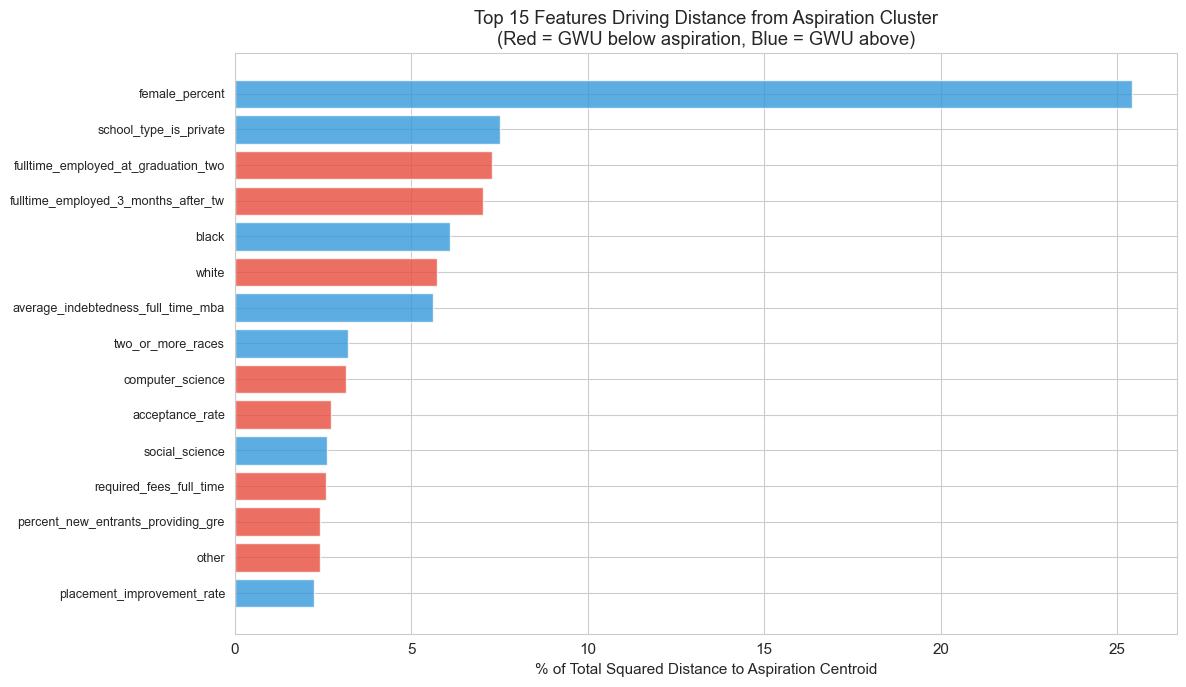


Boundary Schools (GWU's cluster, closest to aspiration centroid):
School                                         Rank   Distance
--------------------------------------------------------------
  Boston University                              46       4.48
  Brandeis University                           100       4.75
  Case Western Reserve University                82       5.08
  Northeastern University                        68       5.35
  George Washington University                   61       5.52 ◄ GWU
  Syracuse University                            54       5.69
  Pace University                               120       6.03
  Suffolk University                            115       6.03
  University of Denver                           97       6.17
  Drexel University                             110       6.35


In [9]:
# Decompose the Euclidean distance from GWU to aspiration centroid by feature
gwu_scaled = df_scaled.values[gwu_idx]
asp_centroid = cl['kmeans_centroids'][aspiration_cluster_id]

# Per-feature squared distance contribution
feature_distances = (gwu_scaled - asp_centroid) ** 2
total_distance = np.sqrt(feature_distances.sum())

# Create ranked feature contribution table
distance_contrib = pd.DataFrame({
    'Feature': df_scaled.columns,
    'Short Name': [c.split('.')[-1][:35] for c in df_scaled.columns],
    'GWU (scaled)': gwu_scaled,
    'Asp. Centroid': asp_centroid,
    'Squared Distance': feature_distances,
    'Pct of Total': 100 * feature_distances / feature_distances.sum(),
    'Direction': ['GWU higher' if gwu_scaled[i] > asp_centroid[i] else 'GWU lower' 
                  for i in range(len(gwu_scaled))],
}).sort_values('Squared Distance', ascending=False)

print(f"Total Euclidean distance from GWU to aspiration centroid: {total_distance:.2f}")
print(f"\nTop 15 features by distance contribution:\n")
print(f"{'Feature':<40s} {'Sq.Dist':>8s} {'%Total':>8s} {'Direction':>12s}")
print("-" * 70)
for _, row in distance_contrib.head(15).iterrows():
    print(f"  {row['Short Name']:<38s} {row['Squared Distance']:>8.3f} {row['Pct of Total']:>7.1f}% {row['Direction']:>12s}")

# Visualize top 15 feature contributions
fig, ax = plt.subplots(figsize=(12, 7))
top15 = distance_contrib.head(15)
colors = ['#e74c3c' if d == 'GWU lower' else '#3498db' for d in top15['Direction']]
ax.barh(range(len(top15)), top15['Pct of Total'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Short Name'].values, fontsize=9)
ax.set_xlabel('% of Total Squared Distance to Aspiration Centroid')
ax.set_title('Top 15 Features Driving Distance from Aspiration Cluster\n(Red = GWU below aspiration, Blue = GWU above)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Boundary schools: schools in GWU's cluster closest to the aspiration cluster
gwu_cluster_mask = kmeans_labels == gwu_cluster_id
gwu_cluster_indices = np.where(gwu_cluster_mask)[0]

distances_to_asp = []
for idx in gwu_cluster_indices:
    d = euclidean(df_scaled.values[idx], asp_centroid)
    distances_to_asp.append((school_names[idx], int(ranks[idx]), d))

distances_to_asp.sort(key=lambda x: x[2])

print("\nBoundary Schools (GWU's cluster, closest to aspiration centroid):")
print(f"{'School':<45s} {'Rank':>5s} {'Distance':>10s}")
print("-" * 62)
for name, rank, dist in distances_to_asp[:10]:
    marker = " ◄ GWU" if name == gwu_name else ""
    print(f"  {name[:43]:<43s} {rank:>5d} {dist:>10.2f}{marker}")

## Summary

| Analysis | Key Finding |
|----------|------------|
| **Regression Model** | Ranking inputs explain the overall score with high R². Placement metrics and salary have the largest coefficients. |
| **Critical Gap** | Employed at graduation (~45% vs. ~65% target) is the single largest drag on GWU's rank. |
| **GWU Strengths** | Salary+bonus, peer assessment, recruiter assessment, and selectivity are already at or above the rank 45-55 band. |
| **What-If** | Improving employed-at-graduation to 60% + employed-3mo to 85% + GMAT to 690 is the combined scenario most likely to reach the target band. |
| **Cluster Transition** | Placement metrics dominate the feature distance from GWU to the aspiration cluster centroid. |
| **Two-Year Lag** | US News uses 2-year rolling averages. Sustained improvement across 2+ years is required. |

**Priority actions:**
1. Employed at graduation: 45% → 60-65% (career services, employer partnerships)
2. Employed 3 months after: 72% → 85%+ (alumni network, post-grad placement)
3. GMAT strategy: evaluate test-optional policy impact on reported median
4. Class size: consider scaling from 90 to ~130 if quality maintained
5. Peer assessment: maintain 3.4+, target 3.5+ via faculty visibility